# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [1]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

2026-06-04 12:24:00.629040: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 12:24:00.637714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780568640.646482    9098 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780568640.649048    9098 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780568640.655582    9098 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [26]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.utils import PyDataset

def get_stl10_memmap():
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )
    base_dir = os.path.dirname(path)
    filepath = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary', 'unlabeled_X.bin')

    # STL-10: 100,000 images, 3 channels, 96x96
    # We use memmap to avoid loading the file into RAM
    # Shape is (N, C, H, W) based on STL-10 binary format
    shape = (100000, 3, 96, 96)
    images_mmap = np.memmap(filepath, dtype='uint8', mode='r', shape=shape)
    
    return images_mmap

class PatchGenerator(PyDataset):
    def __init__(self, images_mmap, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        # Store the pointer to the memmap, keep it as uint8
        self.images = images_mmap 
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            # 1. Load from disk/cache only what we need
            # 2. Transpose from (C, H, W) to (H, W, C)
            # 3. Convert to float and normalize ONLY this one image
            img_cxhxw = self.images[img_idx]
            full_img = img_cxhxw.transpose(2, 1, 0).astype("float32") / 255.0
            
            Y[i] = full_img
            
            # Patch extraction logic
            patches = []
            for r in range(3):
                for c in range(3):
                    y_s, x_s = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_s:y_s+self.patch_size, x_s:x_s+self.patch_size, :]
                    
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin:margin+self.crop_size, margin:margin+self.crop_size, :]
                    patches.append(patch)

            order = np.random.permutation(9)
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [11]:
# Trigger the download and loading
images = get_stl10_memmap()
print(f"Successfully downloaded and memory mapped {images.shape[0]} images.")

Successfully downloaded and memory mapped 100000 images.


In [6]:
print(images.shape)

(100000, 3, 96, 96)


In [12]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [27]:
train_generator = PatchGenerator(images, batch_size=8)
val_generator = PatchGenerator(val_images, batch_size=8)
test_generator = PatchGenerator(test_images, batch_size=8)

Let us inspect the dataset.

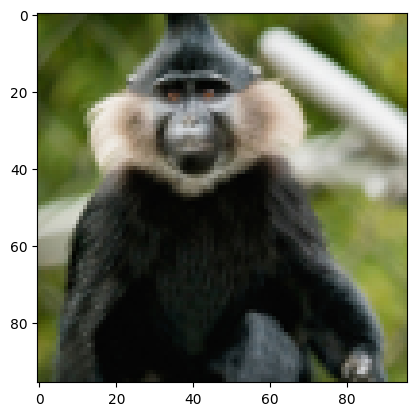

In [29]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(np.transpose(test_images[n],(2,1,0)))

Let us now visualize the puzzle

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [31]:
a,b = test_generator.__getitem__(1)

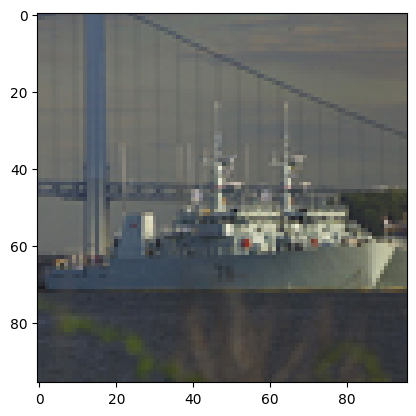

In [32]:
plt.imshow(b[4])

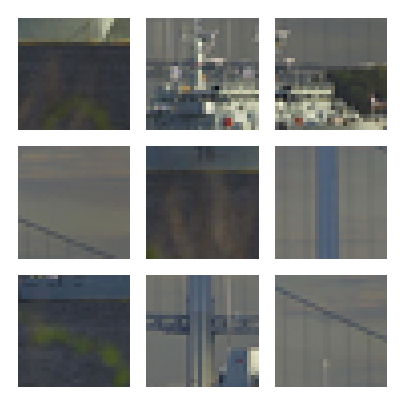

In [33]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [34]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [31]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.1825799, shape=(), dtype=float32)
std: tf.Tensor(0.0011271496, shape=(), dtype=float32)


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.





# Neural solution: soft placement + inpainting

The model below stays fully neural at inference time:

1. A shared CNN encodes each of the 9 scrambled patches.
2. A small Transformer reasons over the 9 patch tokens.
3. A trainable classifier predicts the grid position of each patch.
4. A differentiable **soft-placement layer** creates a 96×96 canvas with the visible 28×28 patch regions centered in their 32×32 cells.
5. A compact U-Net fills only the eroded/missing border pixels.

There is no handcrafted edge matching, search, greedy assignment, or non-neural jigsaw solver. The only fixed operation is the differentiable canvas geometry dictated by the problem definition.


In [ ]:
# Reproducibility
import random
import numpy as np
import tensorflow as tf

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Use TensorFlow/Keras consistently.
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
class PositionPatchGenerator(PyDataset):
    """
    Same patch extraction as the original PatchGenerator, with an optional
    auxiliary target: the true 3x3 grid position of each scrambled patch.

    return_positions=True:
        X: (B, 9, 28, 28, 3)
        y: {
            "reconstruction": (B, 96, 96, 3),
            "position_logits": (B, 9)  # int labels in [0, 8]
        }

    return_positions=False:
        X: (B, 9, 28, 28, 3)
        y: (B, 96, 96, 3)
    """
    def __init__(
        self,
        images_mmap,
        batch_size=32,
        patch_size=32,
        crop_size=28,
        shuffle=True,
        return_positions=False,
        seed=SEED,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.images = images_mmap
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.return_positions = return_positions
        self.indices = np.arange(len(self.images))
        self.rng = np.random.default_rng(seed)
        if self.shuffle:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")
        pos_labels = np.zeros((actual_batch_size, 9), dtype="int32")

        margin = (self.patch_size - self.crop_size) // 2

        for i, img_idx in enumerate(batch_indices):
            img_cxhxw = self.images[img_idx]
            full_img = img_cxhxw.transpose(2, 1, 0).astype("float32") / 255.0
            Y[i] = full_img

            patches = []
            for r in range(3):
                for c in range(3):
                    y_s, x_s = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_s:y_s+self.patch_size, x_s:x_s+self.patch_size, :]
                    patch = patch[margin:margin+self.crop_size, margin:margin+self.crop_size, :]
                    patches.append(patch)

            order = self.rng.permutation(9)
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]
                pos_labels[i, slot_idx] = original_pos

        if self.return_positions:
            return X, {
                "reconstruction": Y,
                "position_logits": pos_labels,
            }
        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)


In [ ]:
@tf.keras.utils.register_keras_serializable(package="Puzzle")
class SoftPuzzleCanvas(layers.Layer):
    """
    Differentiable neural placement layer.

    Inputs:
        patches: (B, 9, 28, 28, 3)
        logits:  (B, 9, 9), where logits[:, p, g] predicts grid position g for patch p

    Outputs:
        canvas: (B, 96, 96, 3), soft-placed visible patch pixels
        mask:   (B, 96, 96, 1), 1 in observed 28x28 crop regions and 0 in erased borders
    """
    def __init__(self, cell_size=32, crop_size=28, temperature=0.5, **kwargs):
        super().__init__(**kwargs)
        self.cell_size = cell_size
        self.crop_size = crop_size
        self.temperature = temperature

    def call(self, inputs):
        patches, logits = inputs
        patches = tf.cast(patches, tf.float32)
        logits = tf.cast(logits, tf.float32)

        # Neural soft assignment. No argmax or search is used.
        probs = tf.nn.softmax(logits / self.temperature, axis=-1)  # (B, patch, grid)

        # For each grid cell, mix patches according to the predicted probabilities.
        grid_patches = tf.einsum("bpg,bphwc->bghwc", probs, patches)  # (B, grid, 28, 28, 3)

        pad = (self.cell_size - self.crop_size) // 2
        grid_patches = tf.pad(
            grid_patches,
            paddings=[[0, 0], [0, 0], [pad, pad], [pad, pad], [0, 0]]
        )  # (B, 9, 32, 32, 3)

        batch_size = tf.shape(patches)[0]
        canvas = tf.reshape(grid_patches, [batch_size, 3, 3, self.cell_size, self.cell_size, 3])
        canvas = tf.transpose(canvas, [0, 1, 3, 2, 4, 5])
        canvas = tf.reshape(canvas, [batch_size, 96, 96, 3])

        # Fixed observed-pixel mask: every cell has a centered 28x28 observed crop.
        ones = tf.ones([batch_size, 9, self.crop_size, self.crop_size, 1], dtype=tf.float32)
        mask_cells = tf.pad(
            ones,
            paddings=[[0, 0], [0, 0], [pad, pad], [pad, pad], [0, 0]]
        )
        mask = tf.reshape(mask_cells, [batch_size, 3, 3, self.cell_size, self.cell_size, 1])
        mask = tf.transpose(mask, [0, 1, 3, 2, 4, 5])
        mask = tf.reshape(mask, [batch_size, 96, 96, 1])

        return canvas, mask

    def get_config(self):
        config = super().get_config()
        config.update({
            "cell_size": self.cell_size,
            "crop_size": self.crop_size,
            "temperature": self.temperature,
        })
        return config


In [ ]:
def conv_bn_act(x, filters, kernel_size=3, strides=1, name=None):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        name=None if name is None else f"{name}_conv"
    )(x)
    x = layers.BatchNormalization(name=None if name is None else f"{name}_bn")(x)
    x = layers.Activation("gelu", name=None if name is None else f"{name}_gelu")(x)
    return x


def build_patch_encoder(token_dim=128):
    patch_in = keras.Input(shape=(28, 28, 3), name="single_patch")

    x = conv_bn_act(patch_in, 32, name="enc_c1")
    x = conv_bn_act(x, 32, name="enc_c2")
    x = conv_bn_act(x, 64, strides=2, name="enc_down1")   # 14x14
    x = conv_bn_act(x, 64, name="enc_c3")
    x = conv_bn_act(x, 96, strides=2, name="enc_down2")   # 7x7
    x = conv_bn_act(x, 96, name="enc_c4")
    x = layers.GlobalAveragePooling2D(name="enc_gap")(x)
    x = layers.Dense(token_dim, name="enc_token")(x)

    return keras.Model(patch_in, x, name="shared_patch_encoder")


def transformer_block(x, token_dim=128, num_heads=4, mlp_dim=256, name="tr"):
    attn_in = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=token_dim // num_heads,
        name=f"{name}_mha"
    )(attn_in, attn_in)
    x = layers.Add(name=f"{name}_attn_add")([x, attn])

    mlp_in = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x)
    mlp = layers.Dense(mlp_dim, activation="gelu", name=f"{name}_mlp1")(mlp_in)
    mlp = layers.Dense(token_dim, name=f"{name}_mlp2")(mlp)
    x = layers.Add(name=f"{name}_mlp_add")([x, mlp])
    return x


def unet_block(x, filters, name, strides=1):
    x = conv_bn_act(x, filters, strides=strides, name=f"{name}_1")
    x = conv_bn_act(x, filters, name=f"{name}_2")
    return x


def build_puzzle_reconstructor(token_dim=128):
    patches_in = keras.Input(shape=(9, 28, 28, 3), name="patches")

    # 1) Encode each patch independently with shared weights.
    patch_encoder = build_patch_encoder(token_dim=token_dim)
    tokens = layers.TimeDistributed(patch_encoder, name="encode_each_patch")(patches_in)

    # 2) Reason globally over all 9 patch tokens.
    x = layers.Dense(token_dim, name="token_projection")(tokens)
    for i in range(3):
        x = transformer_block(x, token_dim=token_dim, num_heads=4, mlp_dim=256, name=f"patch_reasoning_{i+1}")

    # 3) Predict the original grid location of each input patch.
    position_logits = layers.Dense(9, dtype="float32", name="position_logits")(x)

    # 4) Soft neural placement into the known 3x3 geometry.
    placed_canvas, observed_mask = SoftPuzzleCanvas(name="soft_puzzle_canvas")([patches_in, position_logits])

    # 5) Inpaint missing borders/gaps with a compact U-Net.
    inp = layers.Concatenate(name="inpaint_input")([placed_canvas, observed_mask])

    d1 = unet_block(inp, 32, "unet_d1")                      # 96x96
    d2 = unet_block(d1, 48, "unet_d2", strides=2)            # 48x48
    d3 = unet_block(d2, 64, "unet_d3", strides=2)            # 24x24
    d4 = unet_block(d3, 96, "unet_d4", strides=2)            # 12x12
    b  = unet_block(d4, 128, "unet_bottleneck", strides=2)   # 6x6

    u4 = layers.UpSampling2D(name="unet_u4_up")(b)
    u4 = layers.Concatenate(name="unet_u4_cat")([u4, d4])
    u4 = unet_block(u4, 96, "unet_u4")

    u3 = layers.UpSampling2D(name="unet_u3_up")(u4)
    u3 = layers.Concatenate(name="unet_u3_cat")([u3, d3])
    u3 = unet_block(u3, 64, "unet_u3")

    u2 = layers.UpSampling2D(name="unet_u2_up")(u3)
    u2 = layers.Concatenate(name="unet_u2_cat")([u2, d2])
    u2 = unet_block(u2, 48, "unet_u2")

    u1 = layers.UpSampling2D(name="unet_u1_up")(u2)
    u1 = layers.Concatenate(name="unet_u1_cat")([u1, d1])
    u1 = unet_block(u1, 32, "unet_u1")

    fill = layers.Conv2D(3, 1, activation="sigmoid", dtype="float32", name="inpaint_rgb")(u1)

    def preserve_observed_pixels(tensors):
        canvas, mask, predicted_fill = tensors
        return tf.cast(mask * canvas + (1.0 - mask) * predicted_fill, tf.float32)

    reconstruction = layers.Lambda(
        preserve_observed_pixels,
        name="reconstruction",
        output_shape=(96, 96, 3)
    )([placed_canvas, observed_mask, fill])

    model = keras.Model(
        inputs=patches_in,
        outputs=[reconstruction, position_logits],
        name="neural_soft_placement_inpainter"
    )
    return model


model = build_puzzle_reconstructor(token_dim=128)
model.summary()

num_params = model.count_params()
print(f"\nTrainable parameters: {num_params:,}")
assert num_params < 6_000_000, "Parameter budget exceeded."


In [ ]:
# Compile the model.
#
# The submission metric is MAE on the reconstructed image. The position loss is
# an auxiliary neural supervision signal that helps the model learn placement
# faster and more reliably; it is not used as a test metric.

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss={
        "reconstruction": keras.losses.MeanAbsoluteError(),
        "position_logits": keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    loss_weights={
        "reconstruction": 1.0,
        "position_logits": 0.05,
    },
    metrics={
        "reconstruction": [keras.metrics.MeanAbsoluteError(name="mae")],
        "position_logits": [keras.metrics.SparseCategoricalAccuracy(name="pos_acc")],
    },
)


In [ ]:
# Data loaders for training.
# Increase EPOCHS if validation MAE is still improving.

BATCH_SIZE = 64
EPOCHS = 30

train_generator = PositionPatchGenerator(
    train_images,
    batch_size=BATCH_SIZE,
    shuffle=True,
    return_positions=True,
    seed=SEED,
)

val_generator = PositionPatchGenerator(
    val_images,
    batch_size=BATCH_SIZE,
    shuffle=False,
    return_positions=True,
    seed=SEED + 1,
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "puzzle_reconstructor_best.weights.h5",
        monitor="val_reconstruction_mae",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_reconstruction_mae",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_reconstruction_mae",
        mode="min",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
)


In [ ]:
# Optional: load weights from Google Drive using gdown.
#
# To satisfy the assignment rule, after training:
# 1. Upload puzzle_reconstructor_best.weights.h5 to Google Drive.
# 2. Share it as "Anyone with the link can view".
# 3. Paste the file ID below.
#
# Example Drive URL:
# https://drive.google.com/file/d/FILE_ID_HERE/view?usp=sharing

WEIGHTS_GDOWN_ID = ""  # paste your Google Drive file ID here
WEIGHTS_PATH = "puzzle_reconstructor_best.weights.h5"

if WEIGHTS_GDOWN_ID.strip():
    try:
        import gdown
    except ImportError:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
        import gdown

    gdown.download(
        id=WEIGHTS_GDOWN_ID,
        output=WEIGHTS_PATH,
        quiet=False,
    )
    model.load_weights(WEIGHTS_PATH)
    print("Weights downloaded and loaded successfully.")
else:
    print("No gdown file ID configured. Train the model above, then upload weights and paste the ID here.")


In [ ]:
# Evaluate MAE over the test set and report standard deviation per image.

def reconstruction_mae_mean_std(model, generator):
    all_mae = []

    for batch_idx in range(len(generator)):
        patches, target = generator[batch_idx]
        pred = model.predict(patches, verbose=0)

        # Model outputs [reconstruction, position_logits].
        pred_img = pred[0] if isinstance(pred, (list, tuple)) else pred["reconstruction"]

        per_image_mae = np.mean(np.abs(pred_img - target), axis=(1, 2, 3))
        all_mae.extend(per_image_mae.tolist())

    all_mae = np.array(all_mae, dtype=np.float32)
    return float(all_mae.mean()), float(all_mae.std())


test_eval_generator = PositionPatchGenerator(
    test_images,
    batch_size=BATCH_SIZE,
    shuffle=False,
    return_positions=False,
    seed=SEED + 2,
)

test_mae, test_std = reconstruction_mae_mean_std(model, test_eval_generator)
print(f"Test MAE: {test_mae:.6f}")
print(f"Test MAE std: {test_std:.6f}")


In [ ]:
# Visual sanity check: scrambled puzzle, reconstruction, and target.

import matplotlib.pyplot as plt

vis_generator = PositionPatchGenerator(
    test_images,
    batch_size=4,
    shuffle=False,
    return_positions=False,
    seed=SEED + 3,
)

patches, target = vis_generator[0]
pred = model.predict(patches, verbose=0)[0]

n = min(4, patches.shape[0])
for i in range(n):
    plt.figure(figsize=(10, 3))

    plt.subplot(1, 3, 1)
    plot_puzzle(patches[i])
    plt.title("Input scrambled patches")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(np.clip(pred[i], 0, 1))
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(target[i])
    plt.title("Target")
    plt.axis("off")

    plt.show()


In [ ]:
# Save final weights locally.
model.save_weights("puzzle_reconstructor_final.weights.h5")
print("Saved: puzzle_reconstructor_final.weights.h5")


## Parameter report

The exact trainable parameter count is printed by:

```python
model.count_params()
```

The model definition asserts that this count is below 6,000,000. No pretrained weights are used; all weights are trained from scratch on the STL-10 training split.
